# 

In [2]:
import os
os.chdir("..")  # go up one level

In [25]:
import glob
import json
import pandas as pd
import re

paths = glob.glob("calibrationData/gsm8k/additional/**/metadata.json", recursive=True)

rows = []

for path in paths:
    try:
        with open(path, "r") as f:
            data = json.load(f)
        
        data["folder"] = path.rsplit("/", 1)[0]  # keep folder info
        rows.append(data)
        
    except Exception as e:
        print(f"Error reading {path}: {e}")

df = pd.DataFrame(rows)

def get_model_size(model_name):
    match = re.search(r"([\d.]+)\s*B", model_name)
    return float(match.group(1)) if match else None

df = df[df["thinking"] == False]

df = df.set_index( "type")
df = df.sort_index()

In [26]:
df

,model,batch_size,thinking,system_prompt,timestamp,device,max_samples,git_commit,folder
type,,,,,,,,,
float,Qwen/Qwen3-8B,32,False,You are a direct mathematical calculator.\n\nI...,20260626_152128,cuda,None,3f6eb6808d92e016c189034653b9243ee09736cb,calibrationData/gsm8k/additional/run_20260626_...
int,Qwen/Qwen3-8B,32,False,You are a direct mathematical calculator.\n\nI...,20260626_152630,cuda,None,f7e6a9cbf2b0536eecb0483f81671d131e0ee371,calibrationData/gsm8k/additional/run_20260626_...
string,Qwen/Qwen3-8B,32,False,You are a direct mathematical calculator.\n\nI...,20260626_153243,cuda,None,04f25afdf361cb8b6e5e1926e99a9de53b1fca9d,calibrationData/gsm8k/additional/run_20260626_...


In [27]:
import numpy as np
import re

def preprocess_gsm8k(df):
    df["log_conf"] = df["logprobs"].apply(lambda xs: np.exp(sum(xs)/len(xs)) if xs else 0.5)
    
    
    def extract_answer(text):
        match = re.search(r"####\s*(\-?\d+\.?\d*)", text)
        return float(match.group(1)) if match else None
    
    df["full_answer"] = df["answer"]
    df["answer"] = df["full_answer"].apply(extract_answer)
    
    def parse_prediction(pred):
        match = re.findall(r"-?\d+\.?\d*", str(pred))
        return float(match[-1]) if match else None
    
    df["prediction"] = df["prediction"].apply(parse_prediction)
    df["correct"] = df["answer"] == df["prediction"]

In [28]:
from src import metrics
def process_df(df):
    for t, row in df.iterrows():
        file = row["folder"] + "/outputs.jsonl"
        output_file = pd.read_json(file, lines=True)
        preprocess_gsm8k(output_file)

        for method in ["verb" , "log"]:
            mask = output_file[f"{method}_conf"].notna()

            y_true = output_file.loc[mask, "correct"]
            y_conf = output_file.loc[mask, f"{method}_conf"]
            
            ece_values = metrics.bootstrap_ece(output_file["correct"], output_file[f"{method}_conf"], n_bootstrap=10)
            
            df.loc[t,f"{method}_ece"] = ece_values["ece"]
            df.loc[t,f"{method}_ece_se"] = ece_values["se"]
            
            df.loc[t,f"{method}_brier"] = metrics.brier_score_loss(y_true, y_conf)
            df.loc[t,f"{method}_ap"] = metrics.average_precision_score(y_true, y_conf)
            df.loc[t,f"{method}_roc_auc"] = metrics.roc_auc_score(y_true, y_conf)
            
        df.loc[t,"acc"] = output_file["correct"].mean()
        df.loc[t,"num_samples"] = output_file.shape[0]
            
process_df(df)
df

,model,batch_size,thinking,system_prompt,timestamp,device,max_samples,git_commit,folder,verb_ece,...,verb_brier,verb_ap,verb_roc_auc,log_ece,log_ece_se,log_brier,log_ap,log_roc_auc,acc,num_samples
type,,,,,,,,,,,,,,,,,,,,,
float,Qwen/Qwen3-8B,32,False,You are a direct mathematical calculator.\n\nI...,20260626_152128,cuda,None,3f6eb6808d92e016c189034653b9243ee09736cb,calibrationData/gsm8k/additional/run_20260626_...,0.722896,...,0.722688,0.276755,0.501968,0.546939,0.012665,0.472035,0.736171,0.838533,0.275967,1319.0
int,Qwen/Qwen3-8B,32,False,You are a direct mathematical calculator.\n\nI...,20260626_152630,cuda,None,f7e6a9cbf2b0536eecb0483f81671d131e0ee371,calibrationData/gsm8k/additional/run_20260626_...,0.694655,...,0.694708,0.289373,0.515851,0.542425,0.013796,0.473258,0.738162,0.832357,0.282790,1319.0
string,Qwen/Qwen3-8B,32,False,You are a direct mathematical calculator.\n\nI...,20260626_153243,cuda,None,04f25afdf361cb8b6e5e1926e99a9de53b1fca9d,calibrationData/gsm8k/additional/run_20260626_...,0.721569,...,0.718300,0.278549,0.512004,0.554059,0.013754,0.477663,0.756165,0.856932,0.273692,1319.0


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

verb_cols = [c for c in df.columns if c.startswith("verb_") and not c.endswith("_se")] + ["acc"]

plot_df = (
    df[verb_cols]
    .reset_index(names="type")
    .melt(id_vars="type", var_name="metric", value_name="value")
)

plot_df["metric"] = plot_df["metric"].str.replace("verb_", "", regex=False)

<Axes: xlabel='metric', ylabel='value'>

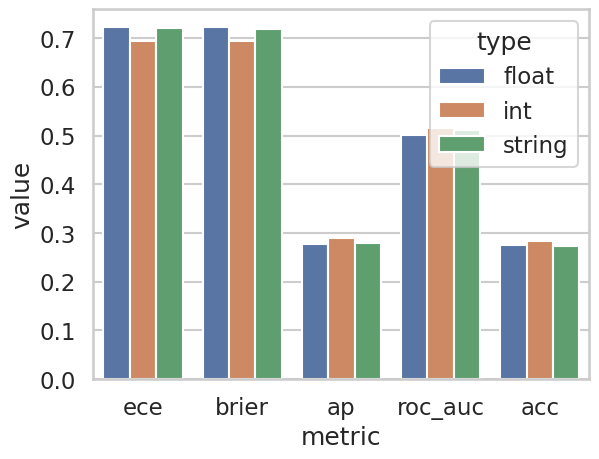

In [31]:
## plot metrics with seaborn

sns.barplot(
    data=plot_df,
    x="metric",
    y="value",
    hue="type",
)

In [32]:
import numpy as np
import pandas as pd

def process_df(df):
    records = []
    for t, row in df.iterrows():
        file = row["folder"] + "/outputs.jsonl"
        output_file = pd.read_json(file, lines=True)
        preprocess_gsm8k(output_file)

        rec = {
            "model": row["model"],
            "type" : t,
            "acc": output_file["correct"].mean(),
            "num_samples": len(output_file),
        }

        for method in ["verb", "log"]:
            conf_col = f"{method}_conf"
            mask = output_file[conf_col].notna()

            y_true = output_file.loc[mask, "correct"].to_numpy()
            y_conf = output_file.loc[mask, conf_col].to_numpy()

            # calibration bins (equal-frequency / deciles)
            if len(y_conf) == 0:
                rec[f"{method}_bin_conf"] = [np.nan] * 10
                rec[f"{method}_bin_acc"] = [np.nan] * 10
            else:
                cal_df = pd.DataFrame({
                    "conf": y_conf,
                    "correct": y_true,
                }).sort_values("conf")

                # qcut on rank index → stable 10 equal-frequency bins
                cal_df["pool"] = pd.qcut(
                    np.arange(len(cal_df)),
                    q=10,
                    labels=False
                )

                pool_stats = (
                    cal_df.groupby("pool")
                    .agg(
                        avg_conf=("conf", "mean"),
                        avg_acc=("correct", "mean"),
                    )
                    .reindex(range(10))  # ensure all bins exist
                )

                rec[f"{method}_bin_conf"] = pool_stats["avg_conf"].tolist()
                rec[f"{method}_bin_acc"] = pool_stats["avg_acc"].tolist()

        records.append(rec)

    summary = pd.DataFrame.from_records(records)
    return summary


results = process_df(df)


In [33]:
results

,model,type,acc,num_samples,verb_bin_conf,verb_bin_acc,log_bin_conf,log_bin_acc
0,Qwen/Qwen3-8B,float,0.275967,1319,"[0.9886363636363636, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.30303030303030304, 0.3333333333333333, 0.27...","[0.3854409064927737, 0.570930290448978, 0.6853...","[0.03787878787878788, 0.08333333333333333, 0.0..."
1,Qwen/Qwen3-8B,int,0.282790,1319,"[0.7640151515151514, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.29545454545454547, 0.3409090909090909, 0.28...","[0.3863336604510324, 0.5718932125593232, 0.688...","[0.07575757575757576, 0.11363636363636363, 0.0..."
2,Qwen/Qwen3-8B,string,0.273692,1319,"[0.9526515151515151, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.30303030303030304, 0.29545454545454547, 0.2...","[0.3869130638758817, 0.5708608649938532, 0.690...","[0.05303030303030303, 0.07575757575757576, 0.0..."


In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_calibration(df, method="verb"):
    data = df.reset_index()

    data = data.explode([f"{method}_bin_conf", f"{method}_bin_acc"])
    

    fig, ax = plt.subplots(figsize=(7, 5))

    # 1. Define colormap and normalize based on the model_size range
    cmap = "flare"

    # 2. Plot the data (Fix: Removed trailing 'co')
    sns.lineplot(
        data=data, 
        x=f"{method}_bin_conf", 
        y=f"{method}_bin_acc", 
        hue="type", 
        markers="o", 
        legend=True, 
        palette=cmap, 
        ax=ax
    )
    
    # 4. Standard formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(f"Calibration") # Added a dynamic title
    
    plt.tight_layout()
    plt.show()

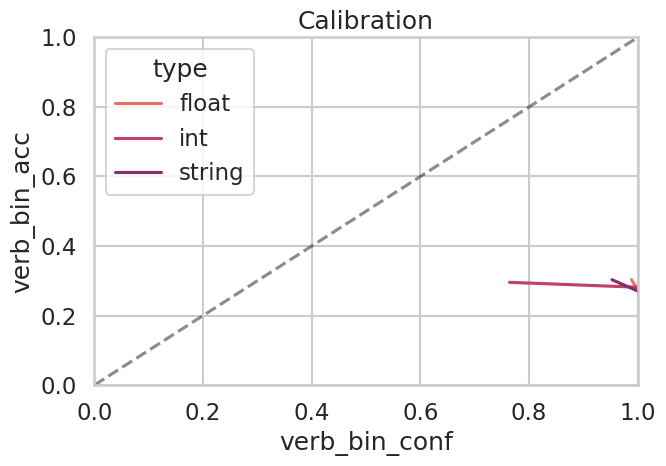

In [37]:
plot_calibration(results, method="verb")